In [1]:
import os, random, math, time
from datetime import datetime, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
BASE_PATH = r"D:\LeakDB_full_data\Hanoi"   
PIPE_PARAMS = r"C:\Users\Jash\OneDrive\Desktop\Research-Project\LeakDB\average_values.csv"    
GRAPH_1_PATH = r"C:\Users\Jash\OneDrive\Desktop\Research-Project\LeakDB\graph_1.csv"        
CHECKPOINT_PATH = "leak_multihead_pinn_checkpoint.pt"

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_NODES = 32
NUM_PIPES = 34
WINDOW_SIZE = 5
BATCH_SIZE = 128
EPOCHS = 30
LR = 1e-3

LAMBDA_MASS = 1e-3
LAMBDA_ENERGY = 1e-3
LAMBDA_MSE = 1e-2

In [4]:
def load_scenario_data(scenario_id, base_path=r"D:\LeakDB_full_data\Hanoi"):
    try:
        scenario_path = os.path.join(base_path, f"Scenario-{scenario_id}")
        if not os.path.exists(scenario_path):
            print(f"Scenario {scenario_id} not found.")
            return None
        
        leaks, timestamps = None, None
        demand_path = flow_path = pressure_path = None
        for sub in os.listdir(scenario_path):
            if sub in [f"Scenario-{scenario_id}", f"Scenario-{scenario_id}_info.csv", f"Hanoi_CMH_Scenario-{scenario_id}.inp"]:
                continue
            sub_path = os.path.join(scenario_path, sub)
            if sub == "Demands":
                demand_path = sub_path
            elif sub == "Flows":
                flow_path = sub_path
            elif sub == "Pressures":
                pressure_path = sub_path
            elif sub == "Labels.csv":
                leaks = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")
            elif sub == "Timestamps.csv":
                timestamps = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")

        if not all([demand_path, flow_path, pressure_path, leaks is not None, timestamps is not None]):
            print(f"Scenario {scenario_id} is incomplete.")
            return None

        df = pd.concat([leaks, timestamps], axis=1, ignore_index=True)
        df.columns = ["Leaks", "Timestamps"]

        def combined_feature_df(path, feature):
            dfs = []
            for file in sorted(os.listdir(path)):
                file_path = os.path.join(path, file)
                if not file.endswith(".csv"):
                    continue
                sub_df = pd.read_csv(file_path).drop(columns="Index", errors="ignore")
                sub_df.columns = [f"{feature}_{file.split('.')[0]}"]
                dfs.append(sub_df)
            return pd.concat(dfs, axis=1, ignore_index=True)

        demand_df = combined_feature_df(demand_path, "demand")
        pressure_df = combined_feature_df(pressure_path, "pressure")
        flow_df = combined_feature_df(flow_path, "flow")

        demand_df.columns = [f"demand_node_{i}" for i in range(1, demand_df.shape[1] + 1)]
        pressure_df.columns = [f"pressure_node_{i}" for i in range(1, pressure_df.shape[1] + 1)]
        flow_df.columns = [f"flow_link_{i}" for i in range(1, flow_df.shape[1] + 1)]

        final_df = pd.concat([demand_df, pressure_df, flow_df, df], axis=1)
        final_df["Leaks"] = final_df["Leaks"].astype(int)
        return final_df

    except Exception as e:
        print(f"Error loading scenario {scenario_id}: {e}")
        return None

In [5]:
def aggregate_nonleak_rows(df, leak_col="Leaks"):
    data_cols = [c for c in df.columns if c != "Timestamps" and c != leak_col]
    out_rows = []
    i = 0
    n = len(df)
    while i < n:
        if df.iloc[i][leak_col] == 1:
            out_rows.append(df.iloc[i][data_cols + [leak_col]].to_dict())
            i += 1
            continue
        j = i
        while j < n and df.iloc[j][leak_col] == 0:
            j += 1
        run_len = j - i
        k = i
        while k + 3 <= j:
            window = df.iloc[k:k+3]
            avg_vals = window[data_cols].mean(axis=0).to_dict()
            avg_vals[leak_col] = 0
            out_rows.append(avg_vals)
            k += 3
        while k < j:
            out_rows.append(df.iloc[k][data_cols + [leak_col]].to_dict())
            k += 1
        i = j
    out_df = pd.DataFrame(out_rows)
    return out_df

In [6]:
def build_windows_from_df(df, window_size=WINDOW_SIZE):
    
    if df is None or len(df) < window_size:
        return np.zeros((0, window_size * 0), dtype=np.float32), np.array([], dtype=np.int64), np.zeros((0,0), dtype=np.float32), []
    
    df2 = df.copy().reset_index(drop=True)
    
    if "Timestamps" in df2.columns:
        df2 = df2.drop(columns=["Timestamps"])
        
    cols = [c for c in df2.columns if c != "Leaks"]
    arr = df2[cols].values.astype(np.float32)
    labels = df2["Leaks"].values.astype(np.int64)
    
    T, F = arr.shape
    X_list, y_list, last_list = [], [], []
    for start in range(0, T - window_size + 1):
        win = arr[start:start+window_size]    
        X_list.append(win.reshape(-1))
        y_list.append(int(labels[start + window_size - 1]))
        last_list.append(win[-1, :])
        
    X = np.stack(X_list, axis=0) if len(X_list)>0 else np.zeros((0, window_size*F), dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)
    last = np.stack(last_list, axis=0) if len(last_list)>0 else np.zeros((0, F), dtype=np.float32)
    
    return X, y, last, cols

In [7]:
def load_pipe_params(pipe_params_csv=PIPE_PARAMS, graph_csv=GRAPH_1_PATH):
    pipe_df = pd.read_csv(pipe_params_csv)
  
    L = torch.tensor(pipe_df.iloc[:NUM_PIPES]["average_length"].values, dtype=torch.float32).to(DEVICE)
    D = torch.tensor(pipe_df.iloc[:NUM_PIPES]["average_diameter"].values, dtype=torch.float32).to(DEVICE)

    if "average_roughness" in pipe_df.columns:
        C = torch.tensor(pipe_df.iloc[:NUM_PIPES]["average_roughness"].values, dtype=torch.float32).to(DEVICE)
    else:
        C = torch.tensor(np.ones(NUM_PIPES, dtype=np.float32), dtype=torch.float32).to(DEVICE)

    gdf = pd.read_csv(graph_csv)
   
    if set(["node1","node2"]).issubset(set(gdf.columns)):
        src = (gdf["node1"].values - 1).astype(int)[:NUM_PIPES]
        dst = (gdf["node2"].values - 1).astype(int)[:NUM_PIPES]
        
    elif set(["start_node","end_node"]).issubset(set(gdf.columns)):
        src = (gdf["start_node"].values - 1).astype(int)[:NUM_PIPES]
        dst = (gdf["end_node"].values - 1).astype(int)[:NUM_PIPES]
        
    else:
        src = np.arange(NUM_PIPES) % NUM_NODES
        dst = (np.arange(NUM_PIPES) + 1) % NUM_NODES
        
    edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long).to(DEVICE)
    
    return L, D, C, edge_index


In [8]:
class WindowDataset(Dataset):
    def __init__(self, X, y, last):
        self.X = X
        self.y = y
        self.last = last
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.last[idx]

In [9]:
class LeakANN(nn.Module):
    def __init__(self, input_dim, hidden1=256, hidden2=128, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)
        self.drop = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden2, 1)
        self.pressure_head = nn.Linear(hidden2, NUM_NODES)
        self.flow_head = nn.Linear(hidden2, NUM_PIPES)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.drop(x)
        leak = torch.sigmoid(self.classifier(x)).squeeze(1)  
        pressure = self.pressure_head(x)                     
        flow = self.flow_head(x)                   
        return leak, pressure, flow

In [10]:
mse_loss_fn = nn.MSELoss()
bce_loss_fn = nn.BCELoss()

In [11]:
def physics_informed_loss(bce_loss, pred_p, pred_f, true_p, true_f, true_d, L_vals, D_vals, C_vals, edge_index,
                          lambda_mass=LAMBDA_MASS, lambda_energy=LAMBDA_ENERGY, lambda_mse=LAMBDA_MSE):

    device = pred_p.device
    B = pred_f.shape[0]
    n_nodes = NUM_NODES
    n_pipes = NUM_PIPES

    flow_in = torch.zeros((B, n_nodes), device=device)
    flow_out = torch.zeros((B, n_nodes), device=device)

    for e in range(n_pipes):
        src = int(edge_index[0, e].item())
        dst = int(edge_index[1, e].item())
        q = pred_f[:, e] 
        flow_out[:, src] += q
        flow_in[:, dst] += q

    mass_imbalance = torch.abs(flow_in - flow_out - true_d)  
    mass_loss = mass_imbalance.mean()

    q_abs = pred_f.abs() + 1e-12
    h_loss = 10.67 * (L_vals.unsqueeze(0) * (q_abs ** 1.852)) / ((C_vals.unsqueeze(0) ** 1.852) * (D_vals.unsqueeze(0) ** 4.87) + 1e-12)  # (B, n_pipes)

    energy_loss = torch.tensor(0.0, device=device)
    for e in range(n_pipes):
        src = int(edge_index[0, e].item())
        dst = int(edge_index[1, e].item())
        pred_drop = pred_p[:, src] - pred_p[:, dst]  
        phys_drop = h_loss[:, e]                     
        energy_loss += torch.mean((pred_drop - phys_drop) ** 2)
    energy_loss = energy_loss / float(n_pipes)

    mse_term = mse_loss_fn(pred_p, true_p) + mse_loss_fn(pred_f, true_f)

    total = bce_loss + lambda_mass * mass_loss + lambda_energy * energy_loss + lambda_mse * mse_term
    
    return total, mass_loss, energy_loss, mse_term

In [12]:
def run_pipeline(sampled_ids, n_train_frac=0.7, n_val_frac=0.15):

    random.shuffle(sampled_ids)
    n_total = len(sampled_ids)
    n_train = int(n_total * n_train_frac)
    n_val = int(n_total * n_val_frac)
    train_ids = sampled_ids[:n_train]
    val_ids = sampled_ids[n_train:n_train+n_val]
    test_ids = sampled_ids[n_train+n_val:]

    L_vals, D_vals, C_vals, edge_index = load_pipe_params(PIPE_PARAMS, GRAPH_1_PATH)

    X_tr, y_tr, last_tr = [], [], []
    X_val, y_val, last_val = [], [], []
    X_test, y_test, last_test = [], [], []

    print("Building windows: train (triple-agg) / val/test (raw)")
    for sid in tqdm(train_ids, desc="train scenarios"):
        df = load_scenario_data(sid)
        if df is None:
            continue
        
        #df_agg = aggregate_nonleak_rows(df)
        X, y, last, cols = build_windows_from_df(df, WINDOW_SIZE)
        
        if len(y) == 0:
            continue
        X_tr.append(X); y_tr.append(y); last_tr.append(last)

    for sid in tqdm(val_ids, desc="val scenarios"):
        df = load_scenario_data(sid)
        if df is None:
            continue
        
        X, y, last, _ = build_windows_from_df(df, WINDOW_SIZE)
        if len(y) == 0:
            continue
        X_val.append(X); y_val.append(y); last_val.append(last)

    for sid in tqdm(test_ids, desc="test scenarios"):
        df = load_scenario_data(sid)
        if df is None:
            continue
        
        X, y, last, _ = build_windows_from_df(df, WINDOW_SIZE)
        if len(y) == 0:
            continue
        X_test.append(X); y_test.append(y); last_test.append(last)

    X_train = np.vstack(X_tr) if len(X_tr)>0 else np.zeros((0, WINDOW_SIZE * (NUM_NODES*2 + NUM_PIPES)), dtype=np.float32)
    y_train = np.concatenate(y_tr) if len(y_tr)>0 else np.array([], dtype=np.int64)
    last_train = np.vstack(last_tr) if len(last_tr)>0 else np.zeros((0, (NUM_NODES*2 + NUM_PIPES)), dtype=np.float32)

    X_val = np.vstack(X_val) if len(X_val)>0 else np.zeros((0, WINDOW_SIZE * (NUM_NODES*2 + NUM_PIPES)), dtype=np.float32)
    y_val = np.concatenate(y_val) if len(y_val)>0 else np.array([], dtype=np.int64)
    last_val = np.vstack(last_val) if len(last_val)>0 else np.zeros((0, (NUM_NODES*2 + NUM_PIPES)), dtype=np.float32)

    X_test = np.vstack(X_test) if len(X_test)>0 else np.zeros((0, WINDOW_SIZE * (NUM_NODES*2 + NUM_PIPES)), dtype=np.float32)
    y_test = np.concatenate(y_test) if len(y_test)>0 else np.array([], dtype=np.int64)
    last_test = np.vstack(last_test) if len(last_test)>0 else np.zeros((0, (NUM_NODES*2 + NUM_PIPES)), dtype=np.float32)

    print("Window counts (train/val/test):", X_train.shape[0], X_val.shape[0], X_test.shape[0])

    if X_train.shape[0] == 0:
        raise RuntimeError("No training data found.")
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0) + 1e-9

    last_mean = last_train.mean(axis=0) if last_train.shape[0]>0 else np.zeros(last_train.shape[1])
    last_std = last_train.std(axis=0) + 1e-9 if last_train.shape[0]>0 else np.ones(last_train.shape[1])

    X_train = (X_train - mean) / std
    X_val = (X_val - mean) / std
    X_test = (X_test - mean) / std

    last_train = (last_train - last_mean) / last_std
    last_val = (last_val - last_mean) / last_std
    last_test = (last_test - last_mean) / last_std

    np.savetxt("train_mean.txt", mean)
    np.savetxt("train_std.txt", std)
    np.savetxt("last_mean.txt", last_mean)
    np.savetxt("last_std.txt", last_std)
    print("Saved train mean/std.")

    train_ds = WindowDataset(X_train, y_train, last_train)
    val_ds = WindowDataset(X_val, y_val, last_val)
    test_ds = WindowDataset(X_test, y_test, last_test)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    input_dim = X_train.shape[1]
    model = LeakANN(input_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    history = {"train_loss":[], "train_mass":[], "train_energy":[], "train_mse":[],
               "val_loss":[], "val_mass":[], "val_energy":[], "val_mse":[], "val_f1":[]}

    best_val_f1 = -1.0
    for epoch in range(1, EPOCHS+1):
        model.train()
        running_loss = running_mass = running_energy = running_mse = 0.0
        for xb, yb, lastb in train_loader:
            xb = xb.to(DEVICE).float()
            yb = yb.to(DEVICE).float()
            lastb = lastb.to(DEVICE).float()

            opt.zero_grad()
            leak_pred, p_pred, f_pred = model(xb)

            demands = lastb[:, :NUM_NODES]
            true_p = lastb[:, NUM_NODES:NUM_NODES*2]
            true_f = lastb[:, NUM_NODES*2:NUM_NODES*2+NUM_PIPES]

            bce = bce_loss_fn(leak_pred, yb)
            total_loss, mass_loss, energy_loss, mse_term = physics_informed_loss(
                bce, p_pred, f_pred, true_p, true_f, demands, L_vals, D_vals, C_vals, edge_index,
                lambda_mass=LAMBDA_MASS, lambda_energy=LAMBDA_ENERGY, lambda_mse=LAMBDA_MSE
            )

            total_loss.backward()
            opt.step()

            running_loss += total_loss.item()
            running_mass += mass_loss.item()
            running_energy += energy_loss.item()
            running_mse += mse_term.item()

        model.eval()
        val_loss = val_mass = val_energy = val_mse = 0.0
        preds_val = []
        labs_val = []
        with torch.no_grad():
            for xb, yb, lastb in val_loader:
                xb = xb.to(DEVICE).float()
                yb = yb.to(DEVICE).float()
                lastb = lastb.to(DEVICE).float()
                leak_pred, p_pred, f_pred = model(xb)
                
                num_true_pos = yb.sum().item()
                num_pred_pos = (leak_pred.squeeze() >= 0.5).sum().item()
                print(f"val positives: {num_true_pos} | predicted positives: {num_pred_pos}")

                demands = lastb[:, :NUM_NODES]
                true_p = lastb[:, NUM_NODES:NUM_NODES*2]
                true_f = lastb[:, NUM_NODES*2:NUM_NODES*2+NUM_PIPES]
                bce = bce_loss_fn(leak_pred, yb)
                total_v, mass_v, energy_v, mse_v = physics_informed_loss(
                    bce, p_pred, f_pred, true_p, true_f, demands, L_vals, D_vals, C_vals, edge_index,
                    lambda_mass=LAMBDA_MASS, lambda_energy=LAMBDA_ENERGY, lambda_mse=LAMBDA_MSE
                )
                val_loss += total_v.item()
                val_mass += mass_v.item()
                val_energy += energy_v.item()
                val_mse += mse_v.item()
                preds_val.append(leak_pred.cpu().numpy())
                labs_val.append(yb.cpu().numpy())

        n_train_batches = max(1, len(train_loader))
        n_val_batches = max(1, len(val_loader))

        avg_loss = running_loss / n_train_batches
        avg_mass = running_mass / n_train_batches
        avg_energy = running_energy / n_train_batches
        avg_mse = running_mse / n_train_batches

        val_loss = val_loss / n_val_batches
        val_mass = val_mass / n_val_batches
        val_energy = val_energy / n_val_batches
        val_mse = val_mse / n_val_batches

        if preds_val:
            preds_val = np.concatenate(preds_val)
            labs_val = np.concatenate(labs_val)
            pred_labels_val = (preds_val >= 0.5).astype(int)
            val_f1 = f1_score(labs_val, pred_labels_val, zero_division=0)
        else:
            val_f1 = 0.0

        history["train_loss"].append(avg_loss)
        history["train_mass"].append(avg_mass)
        history["train_energy"].append(avg_energy)
        history["train_mse"].append(avg_mse)
        history["val_loss"].append(val_loss)
        history["val_mass"].append(val_mass)
        history["val_energy"].append(val_energy)
        history["val_mse"].append(val_mse)
        history["val_f1"].append(val_f1)

        print(f"Epoch {epoch}/{EPOCHS} | train_loss {avg_loss:.4f} | val_loss {val_loss:.4f} | val_f1 {val_f1:.4f} | mass {avg_mass:.3f} | energy {avg_energy:.3f} | mse {avg_mse:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": opt.state_dict(),
                "history": history,
                "mean": mean, "std": std, "last_mean": last_mean, "last_std": last_std
            }, CHECKPOINT_PATH)
            print("Saved checkpoint:", CHECKPOINT_PATH)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.title("Loss"); plt.legend()
    plt.subplot(1,3,2)
    plt.plot(history["train_mass"], label="train_mass"); plt.plot(history["val_mass"], label="val_mass"); plt.title("Mass"); plt.legend()
    plt.subplot(1,3,3)
    plt.plot(history["train_energy"], label="train_energy"); plt.plot(history["val_energy"], label="val_energy"); plt.title("Energy"); plt.legend()
    plt.tight_layout(); plt.savefig("train_history.png", dpi=150); plt.show()

    ck = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ck["model_state"])
    model.to(DEVICE)
    model.eval()

    probs = []
    labels = []
    with torch.no_grad():
        for xb, yb, _ in test_loader:
            xb = xb.to(DEVICE).float()
            leak_pred, _, _ = model(xb)
            probs.extend(leak_pred.cpu().numpy())
            labels.extend(yb.numpy())
    probs = np.array(probs)
    labels = np.array(labels)

    if len(labels) == 0:
        print("No test windows found.")
        return {"model": model, "history": history}

    auc = roc_auc_score(labels, probs)
    fpr, tpr, th = roc_curve(labels, probs)
    j = tpr - fpr
    best_idx = np.argmax(j)
    best_threshold = th[best_idx]

    pred_labels = (probs >= best_threshold).astype(int)
    cm = confusion_matrix(labels, pred_labels)
    prec = precision_score(labels, pred_labels, zero_division=0)
    rec = recall_score(labels, pred_labels, zero_division=0)
    f1 = f1_score(labels, pred_labels, zero_division=0)
    acc = accuracy_score(labels, pred_labels)

    print("TEST: AUC={:.4f} | best_th={:.4f} | acc={:.4f} | prec={:.4f} | rec={:.4f} | f1={:.4f}".format(auc, best_threshold, acc, prec, rec, f1))

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.scatter([fpr[best_idx]], [tpr[best_idx]], color="red", label=f"best_th={best_threshold:.3f}")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC (test)"); plt.legend(); plt.grid(True)
    plt.savefig("roc_test.png", dpi=150); plt.show()

    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title("Confusion Matrix"); plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j], ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.savefig("confusion_test.png", dpi=150); plt.show()

    return {
        "model": model, "history": history,
        "test_metrics": {"auc":auc, "threshold":best_threshold, "acc":acc, "prec":prec, "rec":rec, "f1":f1, "cm":cm},
        "mean": mean, "std": std, "last_mean": last_mean, "last_std": last_std,
        "test_ids": test_ids
    }


Building windows: train (triple-agg) / val/test (raw)


test scenarios: 100%|██████████| 8/8 [00:07<00:00,  1.00it/s]


Window counts (train/val/test): 613060 122612 140128
Saved train mean/std.
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
val positives: 0.0 | predicted positives: 0
v

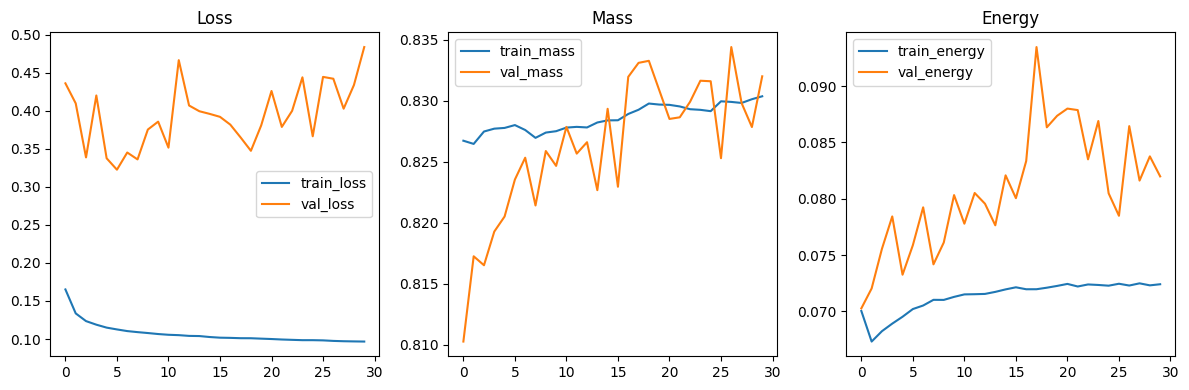

TEST: AUC=0.8888 | best_th=0.6553 | acc=0.8784 | prec=0.9569 | rec=0.7515 | f1=0.8419


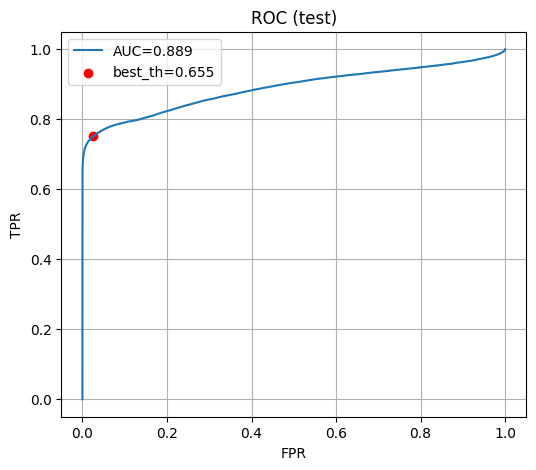

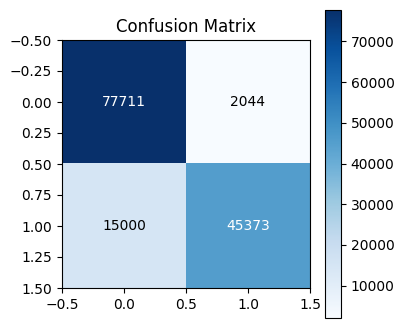

In [13]:
scenarios = list(range(1, 51))
metrics = run_pipeline(scenarios)


In [36]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support, roc_auc_score

def predict_single_scenario(
    model,
    df_raw_id,
    mean_flat_path="train_mean.txt",
    std_flat_path="train_std.txt",
    window_size=5,
    step=1,
    device=None,
    threshold=0.6553,
):
    
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    mean_flat = np.loadtxt(mean_flat_path)
    std_flat = np.loadtxt(std_flat_path)

    df_raw = load_scenario_data(scenario_id=df_raw_id)
    
    if df_raw is None:
        print(f"Scenario-{df_raw_id} is missing.")
        return

    X_windows, y_windows, _, _ = build_windows_from_df(df_raw, window_size=window_size)

    X_norm = (X_windows - mean_flat) / std_flat

    X_tensor = torch.tensor(X_norm, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        leak_pred, pres_pred, flow_pred = model(X_tensor)
    
    leak_probs = leak_pred.cpu().numpy().flatten()
    leak_labels = (leak_probs >= threshold).astype(int)
    y_true = y_windows.astype(int)

    acc = accuracy_score(y_true, leak_labels)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, leak_labels, average="binary", zero_division=0
    )
    auc = roc_auc_score(y_true, leak_probs)

    print("\n===== Scenario Evaluation =====")
    print(f"Threshold used: {threshold:.4f}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")

    cm = confusion_matrix(y_true, leak_labels)
    cm_int = cm.astype(int)

    plt.figure(figsize=(4, 4))
    plt.imshow(cm_int, interpolation="nearest", cmap="Blues")
    plt.title("Confusion Matrix (Scenario)")
    plt.colorbar()

    plt.xticks([0, 1], ["Pred 0", "Pred 1"])
    plt.yticks([0, 1], ["True 0", "True 1"])

    max_val = cm_int.max()
    for i in range(2):
        for j in range(2):
            plt.text(
                j, i,
                cm_int[i, j],
                ha="center", va="center",
                color="white" if cm_int[i, j] > max_val / 2 else "black",
                fontsize=12
            )

    plt.tight_layout()
    plt.show()

    return {
        "probs": leak_probs,
        "labels": leak_labels,
        "truth": y_true,
        "cm": cm,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc
    }


In [15]:
input_dim = 490
model = LeakANN(input_dim).to(DEVICE)
ck = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ck["model_state"])
model.to(DEVICE)

LeakANN(
  (fc1): Linear(in_features=490, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=1, bias=True)
  (pressure_head): Linear(in_features=128, out_features=32, bias=True)
  (flow_head): Linear(in_features=128, out_features=34, bias=True)
)


===== Scenario Evaluation =====
Threshold used: 0.6553
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
AUC      : 1.0000


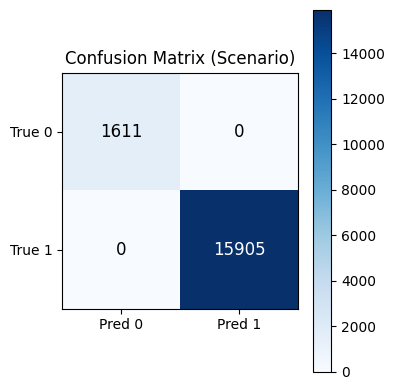

In [42]:
metrics_test = predict_single_scenario(model=model, df_raw_id=46)